## Dragon Real Estate Price Predictor

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from pandas.plotting import scatter_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression



In [3]:
housing_df = pd.read_csv("data.csv")

# housing_pd.head()

# housing_pd['CHAS'].value_counts()

# housing_df.describe()

array([[<Axes: title={'center': 'CRIM'}>, <Axes: title={'center': 'ZN'}>,
        <Axes: title={'center': 'INDUS'}>,
        <Axes: title={'center': 'CHAS'}>],
       [<Axes: title={'center': 'NOX'}>, <Axes: title={'center': 'RM'}>,
        <Axes: title={'center': 'AGE'}>, <Axes: title={'center': 'DIS'}>],
       [<Axes: title={'center': 'RAD'}>, <Axes: title={'center': 'TAX'}>,
        <Axes: title={'center': 'PTRATIO'}>,
        <Axes: title={'center': 'B'}>],
       [<Axes: title={'center': 'LSTAT'}>,
        <Axes: title={'center': 'MEDV'}>, <Axes: >, <Axes: >]],
      dtype=object)

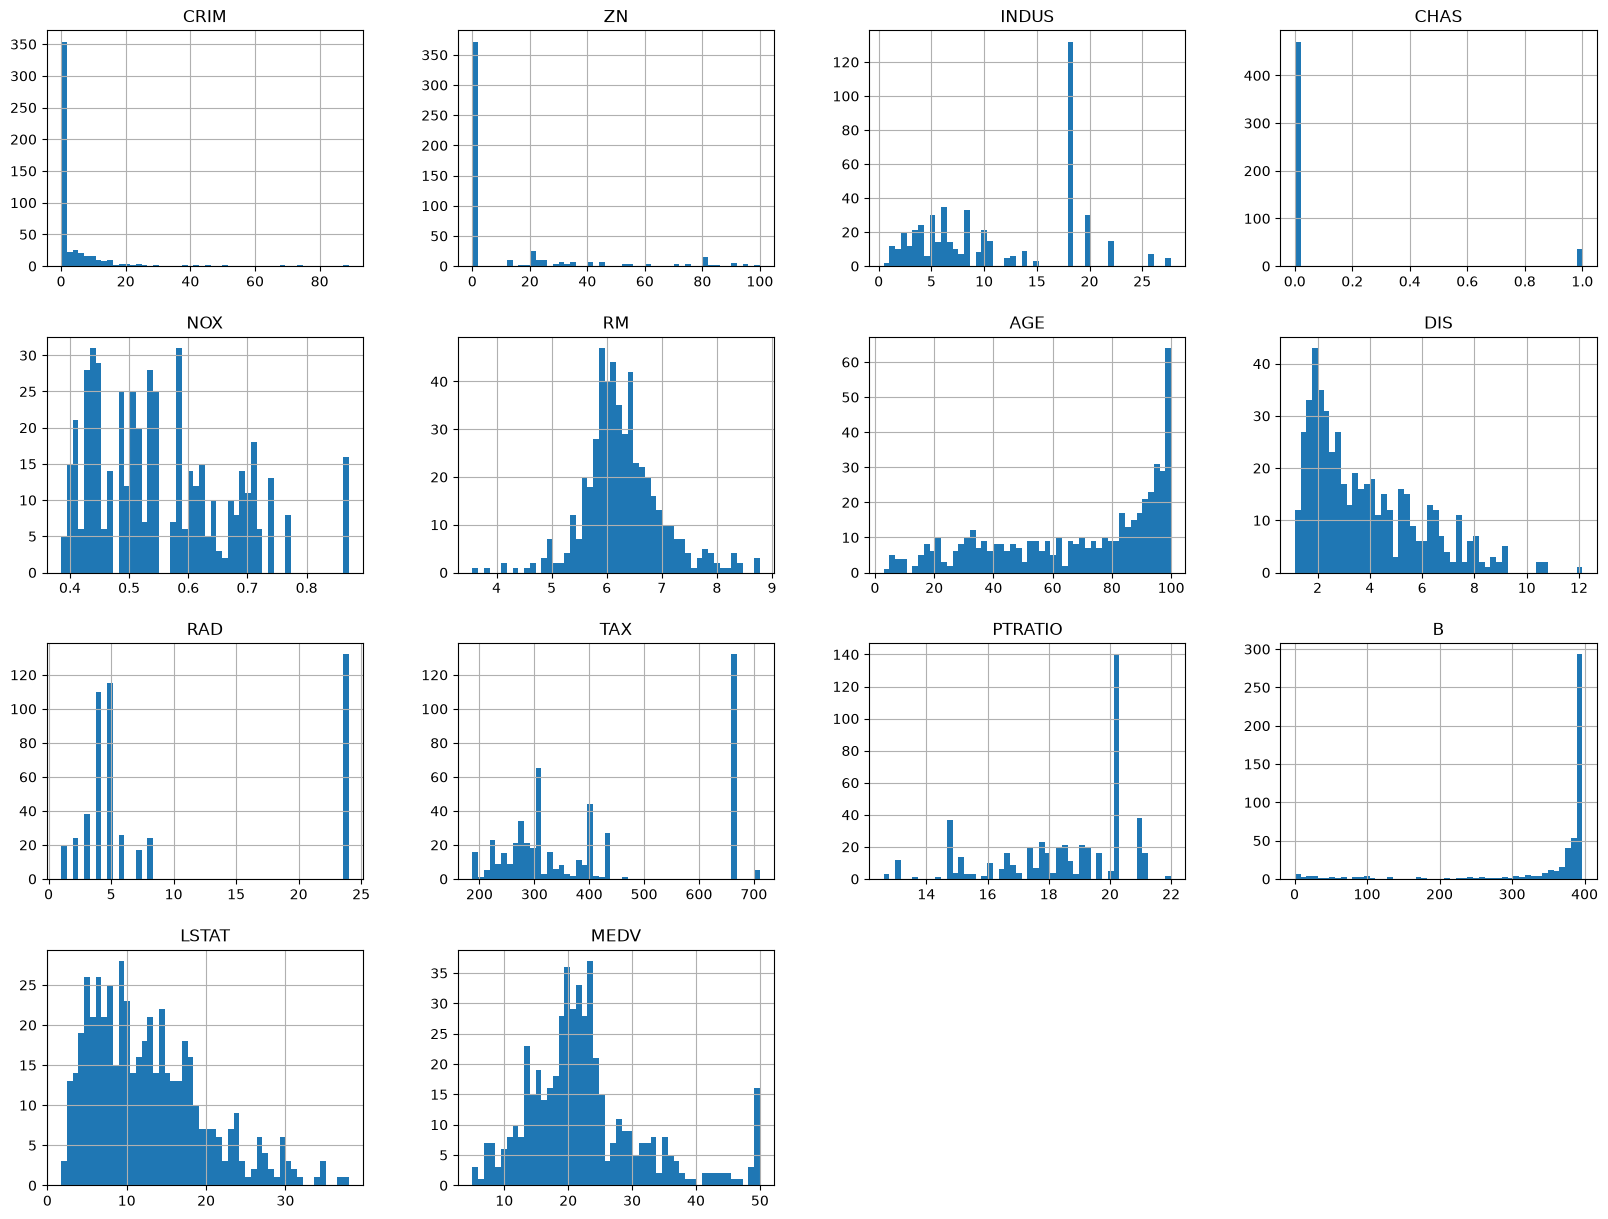

In [6]:
%matplotlib inline
housing_df.hist(bins=50, figsize=(20,15))

## Train-Test Splitting 

In [ ]:
# # for learning purpose
# np.random.seed(42)
# def split_train_test(data, test_ratio):
#     shuffled = np.random.permutation(len(data))
#     test_set_size = int(len(data) * test_ratio)
#     test_indices =  shuffled[:test_set_size]
#     train_indices = shuffled[test_set_size:]
#     return data.iloc[train_indices], data.iloc[test_indices]

# train_set, test_set = split_train_test(housing_df, 0.2)
# print(f"Rows in train set: {len(train_set)} \n Rows n test set: {len(test_set)}")

Rows in train set: 405 
 Rows n test set: 101


In [16]:
train_df, test_df = train_test_split(
    housing_df, 
    test_size=0.2,
    random_state=42,
)
print(f"Rows in train set: {len(train_df)} \n Rows n test set: {len(test_df)}")

Rows in train set: 404 
 Rows n test set: 102


In [26]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing_df, housing_df["CHAS"]):
    strat_train_set = housing_df.loc[train_index]
    strat_test_set = housing_df.loc[test_index]

strat_test_set.info()

<class 'pandas.DataFrame'>
Index: 102 entries, 342 to 218
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     102 non-null    float64
 1   ZN       102 non-null    float64
 2   INDUS    102 non-null    float64
 3   CHAS     102 non-null    int64  
 4   NOX      102 non-null    float64
 5   RM       102 non-null    float64
 6   AGE      102 non-null    float64
 7   DIS      102 non-null    float64
 8   RAD      102 non-null    int64  
 9   TAX      102 non-null    float64
 10  PTRATIO  102 non-null    float64
 11  B        102 non-null    float64
 12  LSTAT    102 non-null    float64
 13  MEDV     102 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 12.0 KB


## Looking for Correlations

In [27]:
corr_matrix = housing_df.corr()
corr_matrix['MEDV'].sort_values(ascending=False)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

array([[<Axes: xlabel='MEDV', ylabel='MEDV'>,
        <Axes: xlabel='RM', ylabel='MEDV'>,
        <Axes: xlabel='ZN', ylabel='MEDV'>,
        <Axes: xlabel='LSTAT', ylabel='MEDV'>],
       [<Axes: xlabel='MEDV', ylabel='RM'>,
        <Axes: xlabel='RM', ylabel='RM'>,
        <Axes: xlabel='ZN', ylabel='RM'>,
        <Axes: xlabel='LSTAT', ylabel='RM'>],
       [<Axes: xlabel='MEDV', ylabel='ZN'>,
        <Axes: xlabel='RM', ylabel='ZN'>,
        <Axes: xlabel='ZN', ylabel='ZN'>,
        <Axes: xlabel='LSTAT', ylabel='ZN'>],
       [<Axes: xlabel='MEDV', ylabel='LSTAT'>,
        <Axes: xlabel='RM', ylabel='LSTAT'>,
        <Axes: xlabel='ZN', ylabel='LSTAT'>,
        <Axes: xlabel='LSTAT', ylabel='LSTAT'>]], dtype=object)

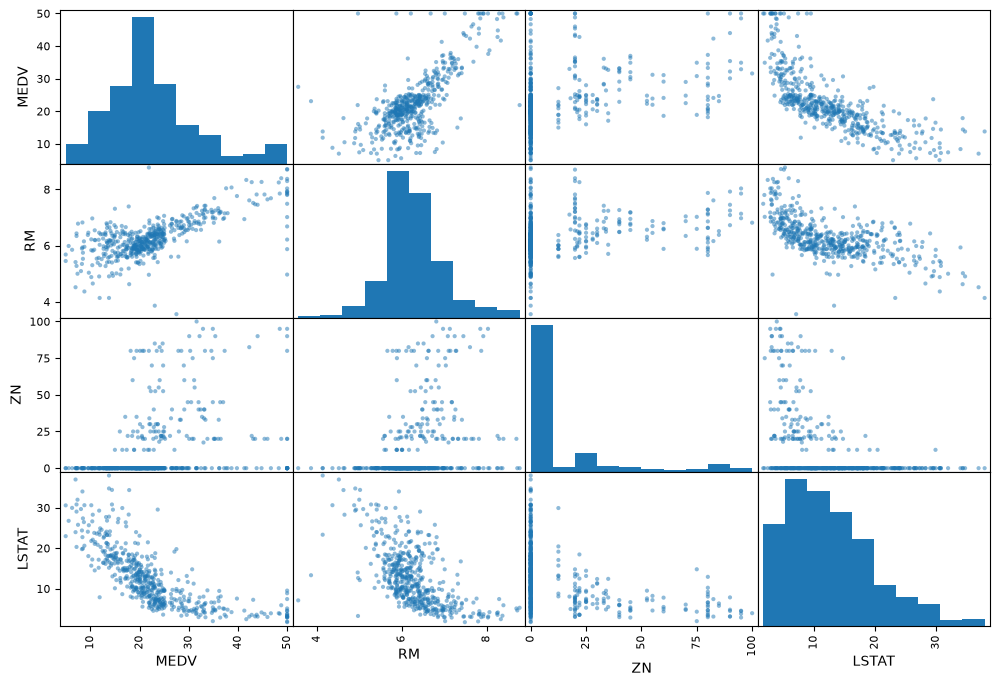

In [29]:
attributes = ["MEDV", "RM", "ZN", "LSTAT"]
scatter_matrix(housing_df[attributes], figsize=(12, 8))

<Axes: xlabel='RM', ylabel='MEDV'>

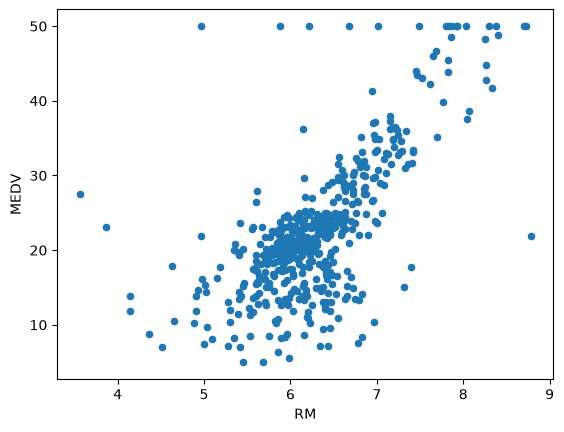

In [30]:
housing_df.plot(kind="scatter", x="RM", y="MEDV", alpha=1)

## Trying Attribute Combinations

In [4]:
housing_df["TAXRM"] = housing_df['TAX']/ housing_df['RM']
housing_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAXRM
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,45.019011
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,37.688834
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,33.681280
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,31.723350
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,31.061984


<Axes: xlabel='TAXRM', ylabel='MEDV'>

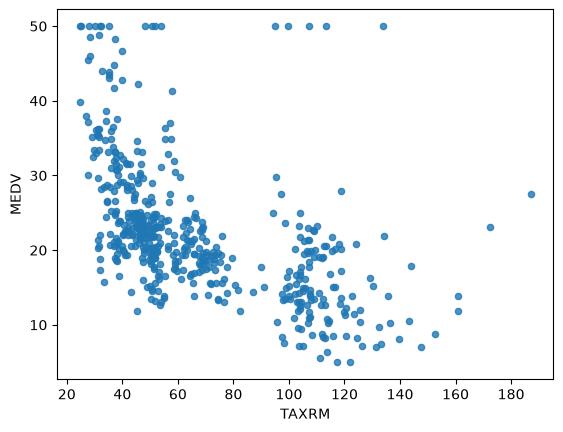

In [5]:
housing_df.plot(kind="scatter", x="TAXRM", y="MEDV", alpha=0.8)

#  Scikit-learn Design
## Primarily , three types of objects
###
1. Estimators - It estimates some parameters based on a dataset. Eg. imputer
It has a fit method and transform method.
Fit method  - Fits the dataset and calculates internal parameters
2. Transformers - transform method takes input and returns outpur based on the learnings from fit(). It also has a convinience  function called fit_transform() which  fits and then transforms.
3. Predictors - LinearRegression model is a example of predictor. fit() and predict() are two common functions. It also gives score() function which will evaluates the predictions.
###

## Feature Scaling
### Primarily , two types of feature scaling methond:

1. Min-max scaling (aka Normalization)
    (value - min)/ (max - min)
    sklearn provides a class called MinMaxScaler for this
2. Standardization
    (value - mean)/std
    Sklearn provides a class called StandardScaler for this

In [9]:
# x = imputer.transform(housing_df)
# housing_df_tr = pd.DataFrame(x, columns=housing_df.columns)

my_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    #       ...... add as many as you want into your pipeline
    ('std_scaler', StandardScaler())
])

housing_num_tr = my_pipeline.fit_transform(housing_df)
housing_num_tr

array([[-0.41978194,  0.28482986, -1.2879095 , ..., -1.0755623 ,
         0.15968566, -0.69357674],
       [-0.41733926, -0.48772236, -0.59338101, ..., -0.49243937,
        -0.10152429, -0.92761003],
       [-0.41734159, -0.48772236, -0.59338101, ..., -1.2087274 ,
         1.32424667, -1.05556065],
       ...,
       [-0.41344658, -0.48772236,  0.11573841, ..., -0.98304761,
         0.14880191, -0.8814641 ],
       [-0.40776407, -0.48772236,  0.11573841, ..., -0.86530163,
        -0.0579893 , -0.84799337],
       [-0.41500016, -0.48772236,  0.11573841, ..., -0.66905833,
        -1.15724782, -0.68544738]], shape=(506, 15))

## Selecting a desired model for Dragon Real Estate

In [ ]:
model = LinearRegression()
# model.fit(housing_num_tr, housing_labets)
